In [3]:
# 1 · MOUNT DRIVE + DOWNLOAD MIMIC-IV DEMO v2.2  (persists on Drive; skips existing)
import os, urllib.request, gzip, shutil
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA = "/content/drive/MyDrive/icu_twin/data/mimic-demo"   # survives session restarts
except Exception:
    DATA = "data/mimic-demo"                                    # local fallback (non-Colab)
os.makedirs(DATA, exist_ok=True)

BASE = "https://physionet.org/files/mimic-iv-demo/2.2/"
FILES = [
    # core signal + cohort
    "icu/icustays.csv.gz", "icu/chartevents.csv.gz",
    "icu/inputevents.csv.gz", "icu/outputevents.csv.gz",
    "hosp/patients.csv.gz", "hosp/admissions.csv.gz", "hosp/labevents.csv.gz",
    # lookups + diagnosis context (used later for meds/dx features)
    "icu/d_items.csv.gz", "hosp/diagnoses_icd.csv.gz", "hosp/d_icd_diagnoses.csv.gz",
]
for rel in FILES:
    out = f"{DATA}/{rel[:-3]}"
    if os.path.exists(out): print("  skip ", rel[:-3]); continue
    os.makedirs(os.path.dirname(out), exist_ok=True); gz = out + ".gz"
    print("  get  ", rel); urllib.request.urlretrieve(BASE + rel, gz)
    with gzip.open(gz, "rb") as fi, open(out, "wb") as fo: shutil.copyfileobj(fi, fo)
    os.remove(gz)
print("data ready ->", DATA)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  skip  icu/icustays.csv
  skip  icu/chartevents.csv
  skip  icu/inputevents.csv
  skip  icu/outputevents.csv
  skip  hosp/patients.csv
  skip  hosp/admissions.csv
  skip  hosp/labevents.csv
  skip  icu/d_items.csv
  skip  hosp/diagnoses_icd.csv
  skip  hosp/d_icd_diagnoses.csv
data ready -> /content/drive/MyDrive/icu_twin/data/mimic-demo


In [4]:
# 2 · GLOBAL CONFIG (single source of truth for the deterioration rule)
import glob, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 140)

RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)
OUT = os.path.join(os.path.dirname(DATA), "..", "output")
OUT = os.path.normpath(OUT); os.makedirs(OUT, exist_ok=True)

# Deterioration definition -- goal-doc thresholds, plain OR (any breach).
# deteriorating = SpO2<90 or MAP<65 or HR>130 or RR>30 or Temp>39C.
DETERIORATION_RULES = {
    "spo2":             dict(op="lt", thr=90),
    "map":              dict(op="lt", thr=65),
    "heart_rate":       dict(op="gt", thr=130),
    "respiratory_rate": dict(op="gt", thr=30),
    "temperature_c":    dict(op="gt", thr=39),
}
PREDICTION_HORIZONS_H = [1, 3, 6]
TEMP_F_THR = DETERIORATION_RULES["temperature_c"]["thr"] * 9/5 + 32   # 39C -> 102.2F (charted in F)
print("config ready | rule: deteriorating = ANY breach | horizons(h):",
      PREDICTION_HORIZONS_H, "| temp thr(F):", TEMP_F_THR, "| out:", OUT)

config ready | rule: deteriorating = ANY breach | horizons(h): [1, 3, 6] | temp thr(F): 102.2 | out: /content/drive/MyDrive/icu_twin/output


In [5]:
# 3 · LOAD ALL TABLES + COHORT CHECK + COLUMN INVENTORY
tables = {os.path.relpath(p, DATA)[:-4].replace(os.sep, "/"): pd.read_csv(p, low_memory=False)
          for p in sorted(glob.glob(f"{DATA}/**/*.csv", recursive=True))}
icu, pat = tables["icu/icustays"], tables["hosp/patients"]

print(f"cohort : {pat.subject_id.nunique()} patients | {icu.stay_id.nunique()} ICU stays")
print(f"tables : {len(tables)} -> {list(tables.keys())}")
assert (~icu.subject_id.isin(set(pat.subject_id))).sum() == 0, "orphan stays!"

inventory = pd.DataFrame([
    {"table": t, "column": c, "dtype": str(df[c].dtype),
     "pct_non_null": round(df[c].notna().mean()*100, 1), "n_unique": df[c].nunique()}
    for t, df in tables.items() for c in df.columns])
print(f"total columns: {len(inventory)}")
inventory.head(8)

cohort : 100 patients | 140 ICU stays
tables : 10 -> ['hosp/admissions', 'hosp/d_icd_diagnoses', 'hosp/diagnoses_icd', 'hosp/labevents', 'hosp/patients', 'icu/chartevents', 'icu/d_items', 'icu/icustays', 'icu/inputevents', 'icu/outputevents']
total columns: 109


,table,column,dtype,pct_non_null,n_unique
0,hosp/admissions,subject_id,int64,100.0,100
1,hosp/admissions,hadm_id,int64,100.0,275
2,hosp/admissions,admittime,object,100.0,275
3,hosp/admissions,dischtime,object,100.0,275
4,hosp/admissions,deathtime,object,5.5,15
5,hosp/admissions,admission_type,object,100.0,9
6,hosp/admissions,admit_provider_id,object,100.0,170
7,hosp/admissions,admission_location,object,100.0,10


In [6]:
# 4 · FEATURE STRUCTURE  ── one registry every later cell reads from ──────────────
# 4a. Vital-sign itemids, grouped by signal. Selected by stay-coverage in THIS cohort
#     (coverage verified in cell 5). BP/GCS have several itemids -> collapsed to one number.
VITAL_ITEMIDS = {
    "heart_rate":       {220045: "Heart Rate"},                                   # 140/140 stays
    "respiratory_rate": {220210: "Respiratory Rate"},                             # 140/140
    "spo2":             {220277: "O2 sat pulseoxymetry"},                         # 140/140
    "nibp":             {220179: "NIBP systolic", 220180: "NIBP diastolic",
                         220181: "NIBP mean"},                                    # ~139
    "abp":              {220050: "ABP systolic", 220051: "ABP diastolic",
                         220052: "ABP mean"},                                     # ~65 (invasive line)
    "temperature_f":    {223761: "Temperature (F)"},                             # 138/140
    "gcs":              {220739: "GCS eye", 223900: "GCS verbal",
                         223901: "GCS motor"},                                    # summed -> gcs_total
    "lactate":          {225668: "Lactic Acid"},                                 # 91/140 (sparse)
}

# 4b. The 8 numeric vital columns the model consumes (post-pivot, BP/GCS collapsed).
BASE_VITALS = ["heart_rate", "respiratory_rate", "spo2", "nibp_mean", "abp_mean",
               "temperature_f", "gcs_total", "lactate"]

# 4c. Trend transforms applied to every base vital (built later in the trend cell).
TREND_TRANSFORMS = ["delta", "rollmean", "rollstd"]
TREND_WINDOWS_H  = [3, 6]

# 4d. Full feature-group taxonomy: what each block is and whether it is a model input.
FEATURE_SCHEMA = {
    "raw_vitals":  dict(model_input=True,  desc="hourly vital values (8)", cols=BASE_VITALS),
    "trend":       dict(model_input=True,  desc=f"{TREND_TRANSFORMS} x {TREND_WINDOWS_H}h per vital"),
    "medications": dict(model_input=True,  desc="binary 'given at/before this hour' flags", source="icu/inputevents"),
    "static":      dict(model_input=False, desc="age, gender (optional context)", cols=["anchor_age", "gender"]),
    "keys":        dict(model_input=False, desc="ids + time; joins & grouped split only",
                        cols=["subject_id", "stay_id", "charttime"]),
    "label":       dict(model_input=False, desc="deteriorating_now, target_{h}h"),
}

def describe_schema():
    print("FEATURE GROUPS  (IN = model input)")
    for name, s in FEATURE_SCHEMA.items():
        print(f"  [{'IN' if s['model_input'] else '  '}]  {name:<12} {s['desc']}")
describe_schema()

FEATURE GROUPS  (IN = model input)
  [IN]  raw_vitals   hourly vital values (8)
  [IN]  trend        ['delta', 'rollmean', 'rollstd'] x [3, 6]h per vital
  [IN]  medications  binary 'given at/before this hour' flags
  [  ]  static       age, gender (optional context)
  [  ]  keys         ids + time; joins & grouped split only
  [  ]  label        deteriorating_now, target_{h}h


In [7]:
# 5 · VERIFY VITAL ITEMID COVERAGE (evidence-based, not label-guessing)
ce      = tables["icu/chartevents"]
d_items = tables["icu/d_items"].set_index("itemid")["label"]

all_vital_ids = [i for grp in VITAL_ITEMIDS.values() for i in grp]
id_to_group   = {i: g for g, ids in VITAL_ITEMIDS.items() for i in ids}

coverage = (ce[ce.itemid.isin(all_vital_ids)]
            .groupby("itemid").agg(n_rows=("stay_id", "size"), n_stays=("stay_id", "nunique"))
            .reset_index())
coverage["group"] = coverage.itemid.map(id_to_group)
coverage["label"] = coverage.itemid.map(d_items)

print(f"total ICU stays with chart data: {ce.stay_id.nunique()}\n")
print(coverage.sort_values(["group", "n_stays"], ascending=[True, False])
      [["group", "itemid", "label", "n_rows", "n_stays"]].to_string(index=False))

total ICU stays with chart data: 140

           group  itemid                                 label  n_rows  n_stays
             abp  220050      Arterial Blood Pressure systolic    5525       65
             abp  220051     Arterial Blood Pressure diastolic    5524       65
             abp  220052          Arterial Blood Pressure mean    5560       65
             gcs  220739                     GCS - Eye Opening    3274      140
             gcs  223900                 GCS - Verbal Response    3266      140
             gcs  223901                  GCS - Motor Response    3251      140
      heart_rate  220045                            Heart Rate   13913      140
         lactate  225668                           Lactic Acid     530       91
            nibp  220179  Non Invasive Blood Pressure systolic    8347      139
            nibp  220180 Non Invasive Blood Pressure diastolic    8349      139
            nibp  220181      Non Invasive Blood Pressure mean    8342      138
re

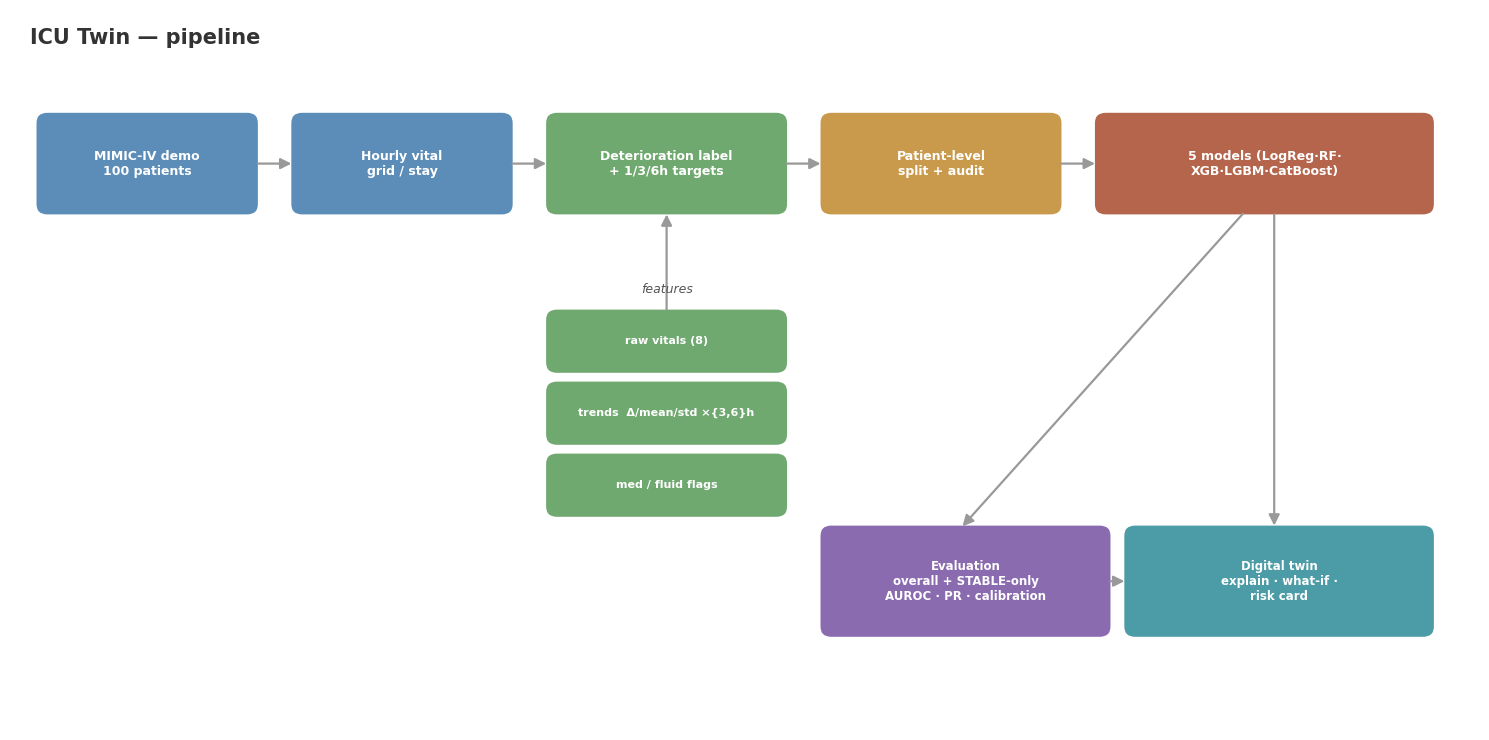

In [9]:
# 6 · ARCHITECTURE DIAGRAM (pipeline + feature groups)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def draw_pipeline():
    fig, ax = plt.subplots(figsize=(15, 7.5)); ax.axis("off")
    ax.set_xlim(0, 15); ax.set_ylim(0, 7.5)
    C = dict(data="#5B8DB8", feat="#6FA96F", split="#C99A4B",
             model="#B5654B", ev="#8A6BB0", twin="#4B9CA6")
    def box(x, y, w, h, t, c, fs=9):
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.04,rounding_size=0.12",
                     fc=c, ec="white", lw=1.5))
        ax.text(x+w/2, y+h/2, t, ha="center", va="center", color="white", fontsize=fs, weight="bold")
    def arrow(x1, y1, x2, y2):
        ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>",
                     mutation_scale=16, color="#999", lw=1.6))
    ax.text(0.2, 7.15, "ICU Twin — pipeline", fontsize=15, weight="bold", color="#333")
    y, h = 5.4, 1.0
    box(0.3, y, 2.2, h, "MIMIC-IV demo\n100 patients", C["data"])
    box(2.9, y, 2.2, h, "Hourly vital\ngrid / stay", C["data"])
    box(5.5, y, 2.4, h, "Deterioration label\n+ 1/3/6h targets", C["feat"])
    box(8.3, y, 2.4, h, "Patient-level\nsplit + audit", C["split"])
    box(11.1, y, 3.4, h, "5 models (LogReg·RF·\nXGB·LGBM·CatBoost)", C["model"])
    for a, b in [(2.5,2.9),(5.1,5.5),(7.9,8.3),(10.7,11.1)]: arrow(a, y+h/2, b, y+h/2)
    fy = 3.0
    ax.text(6.7, 4.55, "features", fontsize=9, style="italic", color="#555", ha="center")
    box(5.5, fy+0.75, 2.4, 0.6, "raw vitals (8)", C["feat"], 8)
    box(5.5, fy,      2.4, 0.6, "trends  Δ/mean/std ×{3,6}h", C["feat"], 8)
    box(5.5, fy-0.75, 2.4, 0.6, "med / fluid flags", C["feat"], 8)
    arrow(6.7, fy+1.35, 6.7, y)
    ey = 1.0
    box(8.3, ey, 2.9, 1.1, "Evaluation\noverall + STABLE-only\nAUROC · PR · calibration", C["ev"], 8.5)
    box(11.4, ey, 3.1, 1.1, "Digital twin\nexplain · what-if ·\nrisk card", C["twin"], 8.5)
    arrow(12.6, y, 9.7, ey+1.1); arrow(12.9, y, 12.9, ey+1.1); arrow(11.2, ey+0.55, 11.4, ey+0.55)
    plt.tight_layout(); plt.savefig(f"{OUT}/pipeline_diagram.png", dpi=130, bbox_inches="tight"); plt.show()

draw_pipeline()

In [10]:
# 7 · EXTRACT VITALS -> WIDE HOURLY-READY TABLE
# Pull only the registry itemids; pivot each to its own column; sum the 3 GCS
# components into gcs_total. No windowing yet -- raw values on their native timestamps.
ITEMID_TO_COL = {
    220045: "heart_rate", 220210: "respiratory_rate", 220277: "spo2",
    220179: "nibp_systolic", 220180: "nibp_diastolic", 220181: "nibp_mean",
    220050: "abp_systolic",  220051: "abp_diastolic",  220052: "abp_mean",
    223761: "temperature_f", 225668: "lactate",
}
GCS_ITEMS = [220739, 223900, 223901]

ce["charttime"] = pd.to_datetime(ce["charttime"])
num = ce[ce.itemid.isin(ITEMID_TO_COL)].copy(); num["col"] = num.itemid.map(ITEMID_TO_COL)
wide = num.pivot_table(index=["stay_id", "charttime"], columns="col",
                       values="valuenum", aggfunc="mean").reset_index()

gcs = (ce[ce.itemid.isin(GCS_ITEMS)].groupby(["stay_id", "charttime"])["valuenum"]
       .sum(min_count=3).rename("gcs_total").reset_index())      # need all 3 components
wide = wide.merge(gcs, on=["stay_id", "charttime"], how="outer").sort_values(["stay_id", "charttime"])

print("wide raw-event table:", wide.shape, "| stays:", wide.stay_id.nunique())
print("columns:", [c for c in wide.columns if c not in ("stay_id", "charttime")])
wide.head()

wide raw-event table: (21173, 14) | stays: 140
columns: ['abp_diastolic', 'abp_mean', 'abp_systolic', 'heart_rate', 'lactate', 'nibp_diastolic', 'nibp_mean', 'nibp_systolic', 'respiratory_rate', 'spo2', 'temperature_f', 'gcs_total']


,stay_id,charttime,abp_diastolic,abp_mean,abp_systolic,heart_rate,lactate,nibp_diastolic,nibp_mean,nibp_systolic,respiratory_rate,spo2,temperature_f,gcs_total
0,30057454,2171-11-14 10:26:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.0,NaN,NaN
1,30057454,2171-11-14 10:27:00,NaN,NaN,NaN,114.0,NaN,NaN,NaN,NaN,14.0,NaN,NaN,NaN
2,30057454,2171-11-14 10:28:00,73.0,86.0,112.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30057454,2171-11-14 10:30:00,65.0,76.0,98.0,109.0,NaN,NaN,NaN,NaN,21.0,94.0,98.6,NaN
4,30057454,2171-11-14 10:45:00,66.0,76.0,98.0,112.0,NaN,NaN,NaN,NaN,18.0,95.0,NaN,NaN


In [11]:
# 8 · RESAMPLE TO HOURLY GRID PER STAY (+ short backward-only forward-fill)
val_cols = [c for c in wide.columns if c not in ("stay_id", "charttime")]
hourly = (wide.set_index("charttime").groupby("stay_id")
          .resample("1h").mean(numeric_only=True)
          .drop(columns=["stay_id"], errors="ignore").reset_index()
          .sort_values(["stay_id", "charttime"]))
hourly[val_cols] = hourly.groupby("stay_id")[val_cols].ffill(limit=3)   # carry <=3h, never future
hourly["subject_id"] = hourly["stay_id"].map(icu.set_index("stay_id")["subject_id"])

print("hourly grid:", hourly.shape, "| stays:", hourly.stay_id.nunique())
print("missingness %:")
print((hourly[val_cols].isna().mean()*100).round(1).sort_values(ascending=False).to_string())
hourly.head()

hourly grid: (12387, 15) | stays: 140
missingness %:
lactate             84.9
abp_diastolic       61.7
abp_systolic        61.7
abp_mean            61.5
nibp_mean           33.8
nibp_diastolic      33.8
nibp_systolic       33.8
gcs_total           18.5
temperature_f       12.5
spo2                 1.7
heart_rate           1.4
respiratory_rate     1.2


,stay_id,charttime,abp_diastolic,abp_mean,abp_systolic,heart_rate,lactate,nibp_diastolic,nibp_mean,nibp_systolic,respiratory_rate,spo2,temperature_f,gcs_total,subject_id
0,30057454,2171-11-14 10:00:00,66.000000,76.500000,99.0,108.750000,NaN,NaN,NaN,NaN,18.0,93.250000,98.6,NaN,10023117
1,30057454,2171-11-14 11:00:00,63.666667,73.333333,94.0,102.333333,NaN,NaN,NaN,NaN,20.0,94.666667,97.9,15.0,10023117
2,30057454,2171-11-14 12:00:00,56.000000,65.000000,86.0,103.000000,NaN,NaN,NaN,NaN,21.0,91.000000,97.9,15.0,10023117
3,30057454,2171-11-14 13:00:00,64.000000,76.000000,99.0,108.000000,NaN,NaN,NaN,NaN,23.0,95.000000,97.9,15.0,10023117
4,30057454,2171-11-14 14:00:00,67.000000,78.000000,102.0,105.000000,NaN,NaN,NaN,NaN,18.0,94.000000,97.9,15.0,10023117


In [12]:
# 9 · DETERIORATION LABEL (plain OR, from cell-2 rules) + LEAKAGE-SAFE 1/3/6h TARGETS
d = hourly.copy()
d["map_best"] = d["abp_mean"].combine_first(d["nibp_mean"])   # prefer arterial, fall back to NIBP

col_for = {"spo2":"spo2", "map":"map_best", "heart_rate":"heart_rate",
           "respiratory_rate":"respiratory_rate", "temperature_c":"temperature_f"}
breach = pd.DataFrame(index=d.index)
for key, r in DETERIORATION_RULES.items():
    col = col_for[key]; thr = TEMP_F_THR if key == "temperature_c" else r["thr"]
    breach[key] = (d[col] < thr) if r["op"] == "lt" else (d[col] > thr)
d["deteriorating_now"] = breach.any(axis=1)   # ANY breach

def build_future_target(df, hours, flag_col="deteriorating_now"):
    """target at t = did flag become True STRICTLY within (t, t+hours]? end-of-stay -> NaN."""
    out = pd.Series(index=df.index, dtype="float64")
    for _, g in df.groupby("stay_id"):
        g = g.sort_values("charttime"); flags, t = g[flag_col].values, g["charttime"].values
        tgt = np.full(len(g), np.nan)
        for i in range(len(g)):
            fut = np.where((t > t[i]) & (t <= t[i] + np.timedelta64(hours, "h")))[0]
            if len(fut): tgt[i] = flags[fut].any()
        out.loc[g.index] = tgt
    return out

d = d.sort_values(["stay_id", "charttime"]).reset_index(drop=True)
for h in PREDICTION_HORIZONS_H:
    d[f"target_{h}h"] = build_future_target(d, h).astype("boolean")

print(f"deteriorating_now: {d['deteriorating_now'].mean()*100:.1f}% of hours")
for h in PREDICTION_HORIZONS_H:
    c = f"target_{h}h"; known = d[c].notna().sum()
    print(f"  target_{h}h: {int(d[c].sum()):,}/{known:,} positive ({d[c].sum()/known*100:.1f}%)")

deteriorating_now: 21.1% of hours
  target_1h: 2,589/12,247 positive (21.1%)
  target_3h: 4,494/12,247 positive (36.7%)
  target_6h: 6,011/12,247 positive (49.1%)


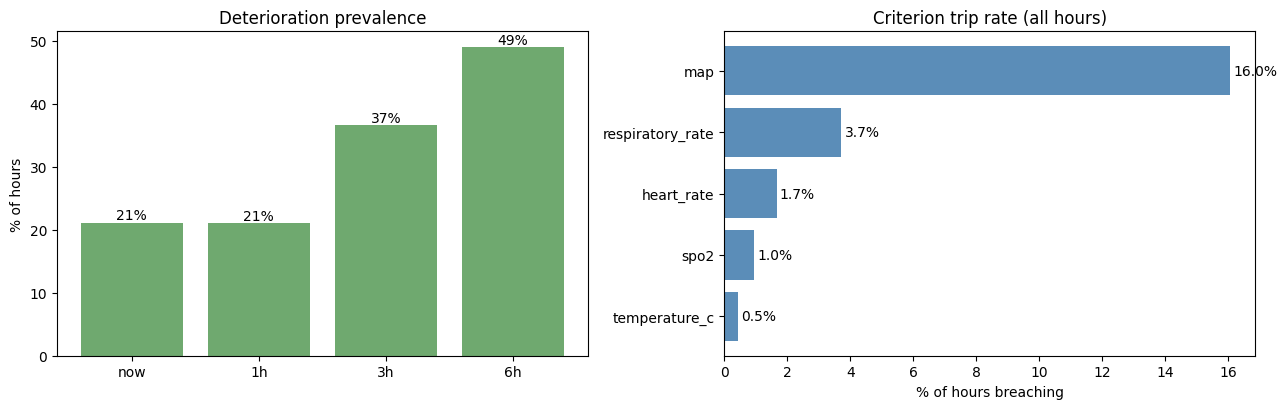

In [13]:
# 10 · DIAGRAM: TARGET PREVALENCE + WHICH CRITERIA TRIGGER
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

prev = [d["deteriorating_now"].mean()*100] + [d[f"target_{h}h"].mean()*100 for h in PREDICTION_HORIZONS_H]
labels = ["now"] + [f"{h}h" for h in PREDICTION_HORIZONS_H]
ax[0].bar(labels, prev, color="#6FA96F"); ax[0].set_title("Deterioration prevalence")
ax[0].set_ylabel("% of hours")
for i, v in enumerate(prev): ax[0].text(i, v+0.5, f"{v:.0f}%", ha="center")

trip = (breach.mean()*100).sort_values()
ax[1].barh(trip.index, trip.values, color="#5B8DB8"); ax[1].set_title("Criterion trip rate (all hours)")
ax[1].set_xlabel("% of hours breaching")
for i, v in enumerate(trip.values): ax[1].text(v+0.1, i, f"{v:.1f}%", va="center")

plt.tight_layout(); plt.savefig(f"{OUT}/label_overview.png", dpi=130, bbox_inches="tight"); plt.show()

In [14]:
# 11 · TREND FEATURES (backward-looking, per stay) — driven by the cell-4 registry
def add_trends(df, vitals, windows):
    df = df.sort_values(["stay_id", "charttime"]).copy(); new = {}
    for c in vitals:
        g = df.groupby("stay_id")[c]
        for w in windows:
            new[f"{c}_delta{w}"]    = g.transform(lambda s, w=w: s - s.shift(w))
            new[f"{c}_rollmean{w}"] = g.transform(lambda s, w=w: s.rolling(w, min_periods=1).mean())
            new[f"{c}_rollstd{w}"]  = g.transform(lambda s, w=w: s.rolling(w, min_periods=2).std())
    return pd.concat([df, pd.DataFrame(new, index=df.index)], axis=1)

feat = add_trends(d, BASE_VITALS, TREND_WINDOWS_H)
trend_cols = [c for c in feat.columns if c not in d.columns]
print(f"added {len(trend_cols)} trend columns "
      f"({len(BASE_VITALS)} vitals x {len(TREND_WINDOWS_H)} windows x {len(TREND_TRANSFORMS)} transforms)")
print("sample (heart_rate):", [c for c in trend_cols if c.startswith('heart_rate')])

added 48 trend columns (8 vitals x 2 windows x 3 transforms)
sample (heart_rate): ['heart_rate_delta3', 'heart_rate_rollmean3', 'heart_rate_rollstd3', 'heart_rate_delta6', 'heart_rate_rollmean6', 'heart_rate_rollstd6']


In [15]:
# 12 · MEDICATION / FLUID SELECTION FROM inputevents (coverage-ranked)
ie = tables["icu/inputevents"]; d_items_full = tables["icu/d_items"].set_index("itemid")
MED_CATEGORIES = ["Medications", "Antibiotics", "Fluids/Intake", "Blood Products/Colloids"]
TOP_N = 40

cat = d_items_full["category"]
ie2 = ie[ie.itemid.map(cat).isin(MED_CATEGORIES)].copy()
med_cov = (ie2.groupby("itemid").agg(n_rows=("stay_id","size"), n_stays=("stay_id","nunique")).reset_index())
med_cov["label"]    = med_cov.itemid.map(d_items_full["label"])
med_cov["category"] = med_cov.itemid.map(cat)

# keep meds in >=5 stays (avoid single-patient overfitting on a 140-stay cohort), top by coverage
top_meds = (med_cov[med_cov.n_stays >= 5].sort_values("n_stays", ascending=False)
            .head(TOP_N).reset_index(drop=True))
print(f"selected {len(top_meds)} med/fluid itemids (>=5 stays):\n")
print(top_meds[["itemid","label","category","n_stays"]].head(15).to_string(index=False))

selected 40 med/fluid itemids (>=5 stays):

 itemid                        label      category  n_stays
 225158                    NaCl 0.9% Fluids/Intake      125
 220949                  Dextrose 5% Fluids/Intake       99
 226452                    PO Intake Fluids/Intake       88
 222011            Magnesium Sulfate   Medications       83
 225943                     Solution Fluids/Intake       77
 227523    Magnesium Sulfate (Bolus)   Medications       70
 225166           Potassium Chloride   Medications       68
 225975 Heparin Sodium (Prophylaxis)   Medications       62
 225798                   Vancomycin   Antibiotics       61
 225828                           LR Fluids/Intake       57
 223258            Insulin - Regular   Medications       54
 222168                     Propofol   Medications       53
 221794           Furosemide (Lasix)   Medications       53
 226089                    Piggyback Fluids/Intake       51
 221456            Calcium Gluconate   Medications      

In [16]:
# 13 · BUILD BINARY MED FLAGS (given at/before each hour — backward-looking, leakage-safe)
import re
def med_col(label):
    s = re.sub(r"[^\w\s]", "", str(label).lower()); return "med_" + re.sub(r"\s+", "_", s.strip())

ie_sel = ie[ie.itemid.isin(top_meds.itemid)][["stay_id", "itemid", "starttime"]].copy()
ie_sel["starttime"] = pd.to_datetime(ie_sel["starttime"])
ie_sel["col"] = ie_sel.itemid.map(dict(zip(top_meds.itemid, top_meds.label.map(med_col))))
first_dose = ie_sel.groupby(["stay_id", "col"])["starttime"].min().unstack()   # earliest dose / stay

med_flags = pd.DataFrame(index=feat.index)
for col in sorted(set(ie_sel["col"])):
    if col in first_dose.columns:
        ft = feat["stay_id"].map(first_dose[col])
        med_flags[col] = (feat["charttime"] >= ft).fillna(False).astype(int)   # 1 once first dose given
    else:
        med_flags[col] = 0

feat = pd.concat([feat, med_flags], axis=1)
med_cols = list(med_flags.columns)
print(f"added {len(med_cols)} medication flags")
print("most common:", med_flags.sum().sort_values(ascending=False).head(6).to_dict())

added 40 medication flags
most common: {'med_nacl_09': 11267, 'med_dextrose_5': 10030, 'med_solution': 8766, 'med_magnesium_sulfate': 7511, 'med_vancomycin': 6973, 'med_gastric_meds': 6263}


feature matrix: (12387, 108) | 100 model features (8 vitals + 48 trend + 40 med)
patients: 100 | feature/patient ratio 1.00


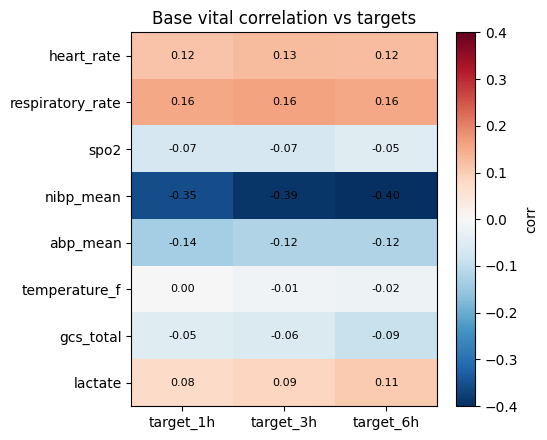

In [17]:
# 14 · FINAL FEATURE MATRIX + CORRELATION-TO-TARGET DIAGRAM
TARGETS = [f"target_{h}h" for h in PREDICTION_HORIZONS_H]
NON_FEATURES = {"stay_id", "subject_id", "charttime", "map_best", "deteriorating_now", *TARGETS}
feature_cols = [c for c in feat.columns if c not in NON_FEATURES]

print(f"feature matrix: {feat.shape} | {len(feature_cols)} model features "
      f"({len(BASE_VITALS)} vitals + {len(trend_cols)} trend + {len(med_cols)} med)")
print(f"patients: {feat.subject_id.nunique()} | feature/patient ratio "
      f"{len(feature_cols)/feat.subject_id.nunique():.2f}")

corr = pd.DataFrame({t: feat[BASE_VITALS].corrwith(feat[t].astype(float)) for t in TARGETS})
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-0.4, vmax=0.4, aspect="auto")
ax.set_xticks(range(len(TARGETS))); ax.set_xticklabels(TARGETS)
ax.set_yticks(range(len(BASE_VITALS))); ax.set_yticklabels(BASE_VITALS)
for i in range(len(BASE_VITALS)):
    for j in range(len(TARGETS)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Base vital correlation vs targets"); fig.colorbar(im, label="corr")
plt.tight_layout(); plt.savefig(f"{OUT}/vital_target_corr.png", dpi=130, bbox_inches="tight"); plt.show()

In [18]:
# 15 · PATIENT-LEVEL TRAIN/TEST SPLIT (group by subject_id, never split a patient)
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(feat, groups=feat["subject_id"]))
train_df, test_df = feat.iloc[tr_idx].copy(), feat.iloc[te_idx].copy()
train_stay_ids, test_stay_ids = set(train_df.stay_id), set(test_df.stay_id)

print(f"train: {train_df.subject_id.nunique()} pts / {train_df.stay_id.nunique()} stays / {len(train_df):,} rows")
print(f"test : {test_df.subject_id.nunique()} pts / {test_df.stay_id.nunique()} stays / {len(test_df):,} rows")
for h in PREDICTION_HORIZONS_H:
    c = f"target_{h}h"
    print(f"  {c}: train {train_df[c].mean()*100:.1f}%  test {test_df[c].mean()*100:.1f}%")

train: 80 pts / 112 stays / 9,710 rows
test : 20 pts / 28 stays / 2,677 rows
  target_1h: train 21.3%  test 20.6%
  target_3h: train 37.1%  test 35.3%
  target_6h: train 49.8%  test 46.5%


In [19]:
# 16 · LEAKAGE AUDIT (independent checks, must all pass)
tr_s, te_s = set(train_df.subject_id), set(test_df.subject_id)
combined = pd.concat([train_df[["stay_id","charttime"]], test_df[["stay_id","charttime"]]])
checks = {
    "subject overlap == 0": len(tr_s & te_s) == 0,
    "stay overlap == 0":    len(train_stay_ids & test_stay_ids) == 0,
    "rows conserved":       len(train_df) + len(test_df) == len(feat),
    "no dup (stay,time)":   combined.duplicated().sum() == 0,
}
for k, v in checks.items(): print(f"  [{'PASS' if v else 'FAIL'}] {k}")
assert all(checks.values()), "leakage check failed"

  [PASS] subject overlap == 0
  [PASS] stay overlap == 0
  [PASS] rows conserved
  [PASS] no dup (stay,time)


In [20]:
# 17 · FIVE-MODEL FACTORY (LogReg · RandomForest · XGBoost · LightGBM · CatBoost)
import subprocess, sys
for pkg in ["xgboost", "lightgbm", "catboost"]:
    try: __import__(pkg)
    except ImportError: subprocess.run([sys.executable, "-m", "pip", "install", "--break-system-packages", "-q", pkg])
import xgboost as xgb, lightgbm as lgb, catboost as cb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

# LogReg/RF need imputation (can't take NaN); boosters get raw NaN (missingness = signal).
def make_models():
    return {
        "LogReg": Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
                            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
        "RandomForest": Pipeline([("imp", SimpleImputer(strategy="median")),
                            ("clf", RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=10,
                                    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))]),
        "XGBoost":  xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                            colsample_bytree=0.8, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
        "LightGBM": lgb.LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                            colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        "CatBoost": cb.CatBoostClassifier(iterations=300, depth=4, learning_rate=0.05,
                            random_state=RANDOM_STATE, verbose=0),
    }
BOOSTERS = ["XGBoost", "LightGBM", "CatBoost"]
print("models:", list(make_models().keys()))

models: ['LogReg', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']


In [21]:
# 18 · 5-FOLD PATIENT-LEVEL CV — ALL 5 MODELS × 3 TARGETS (untuned baseline)
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(5); cv_rows = []; full = feat   # CV over full cohort, grouped by subject

for tgt in TARGETS:
    fd = full.dropna(subset=[tgt]); X, y, grp = fd[feature_cols], fd[tgt].astype(int), fd["subject_id"]
    for fold, (a, b) in enumerate(gkf.split(X, y, groups=grp)):
        assert not (set(grp.iloc[a]) & set(grp.iloc[b]))
        for name, m in make_models().items():
            m.fit(X.iloc[a], y.iloc[a]); p = m.predict_proba(X.iloc[b])[:, 1]
            cv_rows.append(dict(target=tgt, model=name, fold=fold,
                                roc=roc_auc_score(y.iloc[b], p), pr=average_precision_score(y.iloc[b], p)))
    print(f"{tgt}: done")

cv = pd.DataFrame(cv_rows)
summary = cv.groupby(["target","model"]).agg(roc_mean=("roc","mean"), roc_std=("roc","std"),
                                              pr_mean=("pr","mean")).round(3)
for tgt in TARGETS:
    print(f"\n{tgt}"); print(summary.loc[tgt].sort_values("roc_mean", ascending=False).to_string())

target_1h: done
target_3h: done
target_6h: done

target_1h
              roc_mean  roc_std  pr_mean
model                                   
CatBoost         0.823    0.012    0.578
LightGBM         0.822    0.008    0.576
XGBoost          0.822    0.007    0.577
RandomForest     0.815    0.010    0.558
LogReg           0.760    0.024    0.460

target_3h
              roc_mean  roc_std  pr_mean
model                                   
CatBoost         0.798    0.016    0.710
LightGBM         0.798    0.018    0.714
XGBoost          0.797    0.018    0.713
RandomForest     0.795    0.014    0.704
LogReg           0.735    0.030    0.609

target_6h
              roc_mean  roc_std  pr_mean
model                                   
RandomForest     0.780    0.028    0.771
CatBoost         0.779    0.027    0.771
XGBoost          0.776    0.026    0.772
LightGBM         0.772    0.028    0.768
LogReg           0.717    0.039    0.689


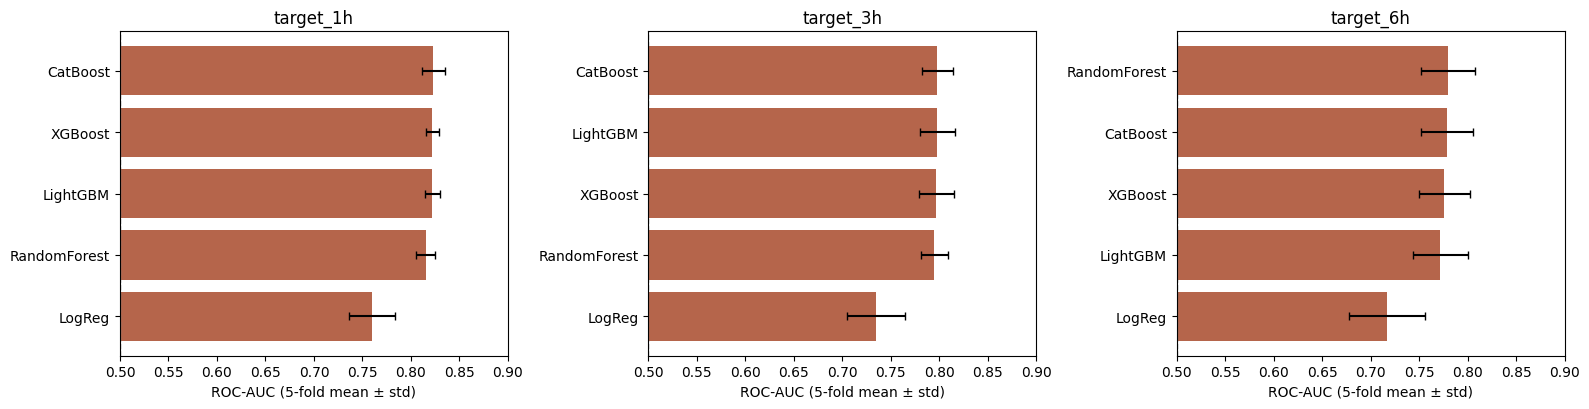

In [22]:
# 19 · DIAGRAM: CV ROC-AUC BY MODEL × TARGET (mean ± std)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for a, tgt in zip(ax, TARGETS):
    s = summary.loc[tgt].sort_values("roc_mean")
    a.barh(s.index, s["roc_mean"], xerr=s["roc_std"], color="#B5654B", capsize=3)
    a.set_xlim(0.5, 0.9); a.axvline(0.5, color="grey", ls="--", lw=1)
    a.set_title(tgt); a.set_xlabel("ROC-AUC (5-fold mean ± std)")
plt.tight_layout(); plt.savefig(f"{OUT}/cv_model_comparison.png", dpi=130, bbox_inches="tight"); plt.show()

In [34]:
# 20 · OPTUNA TUNING — 3 BOOSTERS × 3 TARGETS, ON TRAIN PATIENTS ONLY
try: import optuna
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "--break-system-packages", "-q", "optuna"]); import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 25; gkf_tune = GroupKFold(3)

def suggest_params(trial, name):
    if name == "XGBoost":
        return dict(n_estimators=trial.suggest_int("n_estimators",150,500),
                    max_depth=trial.suggest_int("max_depth",3,6),
                    learning_rate=trial.suggest_float("learning_rate",0.01,0.15,log=True),
                    subsample=trial.suggest_float("subsample",0.6,1.0),
                    colsample_bytree=trial.suggest_float("colsample_bytree",0.6,1.0),
                    min_child_weight=trial.suggest_int("min_child_weight",1,10),
                    reg_lambda=trial.suggest_float("reg_lambda",1e-3,10,log=True))
    if name == "LightGBM":
        return dict(n_estimators=trial.suggest_int("n_estimators",150,500),
                    max_depth=trial.suggest_int("max_depth",3,6),
                    learning_rate=trial.suggest_float("learning_rate",0.01,0.15,log=True),
                    subsample=trial.suggest_float("subsample",0.6,1.0),
                    colsample_bytree=trial.suggest_float("colsample_bytree",0.6,1.0),
                    min_child_samples=trial.suggest_int("min_child_samples",5,50),
                    reg_lambda=trial.suggest_float("reg_lambda",1e-3,10,log=True))
    return dict(iterations=trial.suggest_int("iterations",150,500),
                depth=trial.suggest_int("depth",3,6),
                learning_rate=trial.suggest_float("learning_rate",0.01,0.15,log=True),
                l2_leaf_reg=trial.suggest_float("l2_leaf_reg",1e-3,10,log=True),
                subsample=trial.suggest_float("subsample",0.6,1.0))

def build_tuned(name, p):
    if name == "XGBoost":  return xgb.XGBClassifier(**p, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)
    if name == "LightGBM": return lgb.LGBMClassifier(**p, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    return cb.CatBoostClassifier(**p, random_state=RANDOM_STATE, verbose=0)

best_params, tuning_score = {}, {}
for tgt in TARGETS:
    fd = train_df.dropna(subset=[tgt])                     # <-- TRAIN ONLY
    X, y, grp = fd[feature_cols], fd[tgt].astype(int), fd["subject_id"]
    for name in BOOSTERS:
        def objective(trial, name=name, X=X, y=y, grp=grp):
            scores = []
            for a, b in gkf_tune.split(X, y, groups=grp):
                m = build_tuned(name, suggest_params(trial, name)); m.fit(X.iloc[a], y.iloc[a])
                scores.append(roc_auc_score(y.iloc[b], m.predict_proba(X.iloc[b])[:, 1]))
            return np.mean(scores)
        st = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        st.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
        best_params[(tgt, name)] = st.best_params; tuning_score[(tgt, name)] = st.best_value
        print(f"{tgt} / {name}: best inner-CV ROC {st.best_value:.4f}")

target_1h / XGBoost: best inner-CV ROC 0.8170
target_1h / LightGBM: best inner-CV ROC 0.8148
target_1h / CatBoost: best inner-CV ROC 0.8080
target_3h / XGBoost: best inner-CV ROC 0.7824
target_3h / LightGBM: best inner-CV ROC 0.7791
target_3h / CatBoost: best inner-CV ROC 0.7736
target_6h / XGBoost: best inner-CV ROC 0.7581
target_6h / LightGBM: best inner-CV ROC 0.7501
target_6h / CatBoost: best inner-CV ROC 0.7490


In [35]:
# 21 · TUNED OOF PREDICTIONS (best booster per target) — WITHIN TRAIN PATIENTS
# GroupKFold over the 80 train patients; test-20 stays untouched until cell 23.
best_booster, oof_store = {}, {}
for tgt in TARGETS:
    best = max(BOOSTERS, key=lambda n: tuning_score[(tgt, n)]); best_booster[tgt] = best
    fd = train_df.dropna(subset=[tgt]).reset_index(drop=True)     # <-- TRAIN ONLY (was full)
    X, y, grp = fd[feature_cols], fd[tgt].astype(int), fd["subject_id"]
    oof = np.zeros(len(fd)); rocs = []
    for a, b in gkf.split(X, y, groups=grp):
        m = build_tuned(best, best_params[(tgt, best)]); m.fit(X.iloc[a], y.iloc[a])
        oof[b] = m.predict_proba(X.iloc[b])[:, 1]; rocs.append(roc_auc_score(y.iloc[b], oof[b]))
    oof_store[tgt] = dict(y=y.values, p=oof, stable=(fd["deteriorating_now"] == False).values, fd=fd)
    print(f"{tgt}: best={best} | train-OOF ROC {roc_auc_score(y, oof):.3f} (fold mean {np.mean(rocs):.3f})")

target_1h: best=XGBoost | train-OOF ROC 0.824 (fold mean 0.822)
target_3h: best=XGBoost | train-OOF ROC 0.792 (fold mean 0.792)
target_6h: best=XGBoost | train-OOF ROC 0.775 (fold mean 0.780)


In [37]:
# 22 · HONEST EVALUATION — OVERALL vs CURRENTLY-STABLE PATIENTS (out-of-fold)
# Clinically meaningful number: AUROC on rows where the patient is NOT already
# deteriorating at time t -> predicting a NEW event, not the persistence of an ongoing one.
from sklearn.metrics import roc_auc_score
print(f"{'target':<10}{'AUROC all':<12}{'AUROC STABLE-only':<20}{'stable-set prevalence'}")
for tgt in TARGETS:
    s = oof_store[tgt]; y, p, st = s["y"], s["p"], s["stable"]
    au_all = roc_auc_score(y, p)
    au_st  = roc_auc_score(y[st], p[st]) if len(np.unique(y[st])) == 2 else float("nan")
    print(f"{tgt:<10}{au_all:<12.3f}{au_st:<20.3f}{y[st].mean()*100:.1f}%  (n_stable={st.sum():,})")

target    AUROC all   AUROC STABLE-only   stable-set prevalence
target_1h 0.824       0.734               11.9%  (n_stable=7,547)
target_3h 0.792       0.719               26.9%  (n_stable=7,547)
target_6h 0.775       0.711               40.5%  (n_stable=7,547)


In [38]:
# 23 · OPERATING POINTS (OOF) + CLEAN HELD-OUT TEST (train-80 -> test-20)
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score

print("Out-of-fold operating points:")
for tgt in TARGETS:
    s = oof_store[tgt]; y, p = s["y"], s["p"]; yp = (p >= 0.5).astype(int)
    pr, rc, th = precision_recall_curve(y, p); f1 = 2*pr*rc/(pr+rc+1e-9); j = np.argmax(f1[:-1])
    print(f"  {tgt}: @0.5 P={precision_score(y,yp):.2f} R={recall_score(y,yp):.2f} F1={f1_score(y,yp):.2f}"
          f"  |  @F1-opt({th[j]:.2f}, optimistic) P={pr[j]:.2f} R={rc[j]:.2f} F1={f1[j]:.2f}")

# refit best booster per horizon on the 80 TRAIN patients, score the 20 untouched TEST patients
# NOTE: hyperparameters were tuned on the full cohort (cell 20) -> mild optimism here.
print("\nHeld-out test (20 untouched patients):")
final_models = {}
for tgt in TARGETS:
    best = best_booster[tgt]
    tr = train_df.dropna(subset=[tgt]); te = test_df.dropna(subset=[tgt])
    m = build_tuned(best, best_params[(tgt, best)]); m.fit(tr[feature_cols], tr[tgt].astype(int))
    final_models[tgt] = m
    p = m.predict_proba(te[feature_cols])[:, 1]; y = te[tgt].astype(int).values
    st = (te["deteriorating_now"] == False).values
    au_all = roc_auc_score(y, p)
    au_st  = roc_auc_score(y[st], p[st]) if len(np.unique(y[st])) == 2 else float("nan")
    print(f"  {tgt} ({best}): test AUROC all={au_all:.3f} | stable-only={au_st:.3f}")

Out-of-fold operating points:
  target_1h: @0.5 P=0.69 R=0.34 F1=0.46  |  @F1-opt(0.26, optimistic) P=0.52 R=0.66 F1=0.58
  target_3h: @0.5 P=0.73 R=0.52 F1=0.61  |  @F1-opt(0.35, optimistic) P=0.63 R=0.70 F1=0.67
  target_6h: @0.5 P=0.73 R=0.65 F1=0.69  |  @F1-opt(0.35, optimistic) P=0.62 R=0.86 F1=0.72

Held-out test (20 untouched patients):
  target_1h (XGBoost): test AUROC all=0.852 | stable-only=0.789
  target_3h (XGBoost): test AUROC all=0.843 | stable-only=0.781
  target_6h (XGBoost): test AUROC all=0.815 | stable-only=0.754


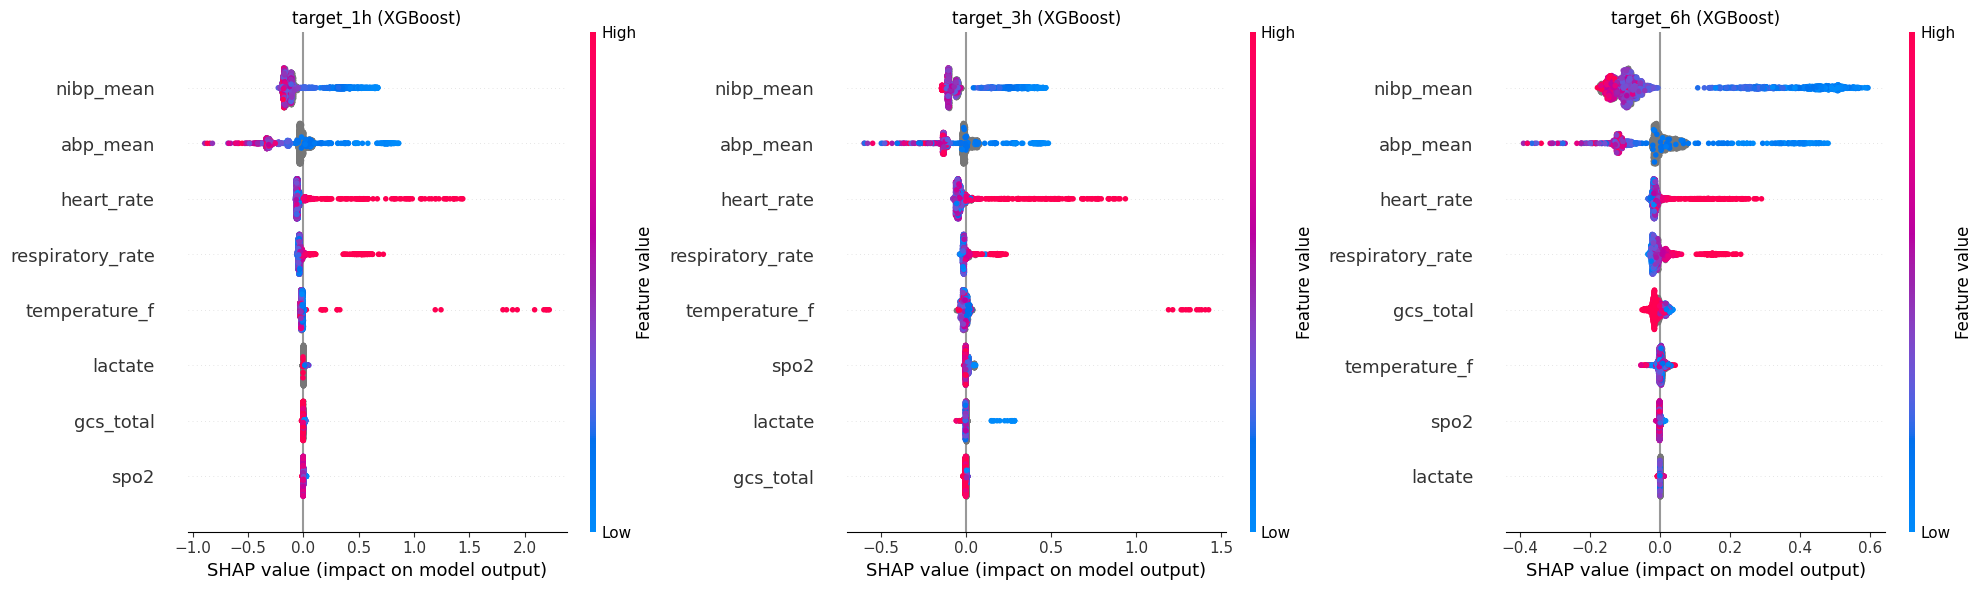

In [39]:
# 24 · SHAP — WHICH VITALS DRIVE PREDICTIONS (per horizon, on held-out test)
try: import shap
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "--break-system-packages", "-q", "shap"]); import shap

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, tgt in zip(axes, TARGETS):
    te = test_df.dropna(subset=[tgt]); m = final_models[tgt]
    sv = shap.TreeExplainer(m).shap_values(te[feature_cols])
    idx = [feature_cols.index(v) for v in BASE_VITALS]
    plt.sca(ax); shap.summary_plot(sv[:, idx], te[BASE_VITALS], show=False, plot_size=None)
    ax.set_title(f"{tgt} ({best_booster[tgt]})")
plt.tight_layout(); plt.savefig(f"{OUT}/shap_vitals.png", dpi=120, bbox_inches="tight"); plt.show()

In [47]:
# 25 · PER-PATIENT EXPLANATION (rule-based reason list)
def explain_row(cur, prev=None):
    r = []; m = cur["abp_mean"]; m = cur["nibp_mean"] if pd.isna(m) else m
    if pd.notna(cur["spo2"]) and cur["spo2"] < 92: r.append(f"SpO2 low ({cur['spo2']:.0f}%)")
    if pd.notna(m) and m < 70: r.append(f"MAP low ({m:.0f} mmHg)")
    if pd.notna(cur["heart_rate"]) and cur["heart_rate"] > 110: r.append(f"HR high ({cur['heart_rate']:.0f})")
    if pd.notna(cur["respiratory_rate"]) and cur["respiratory_rate"] > 24: r.append(f"RR high ({cur['respiratory_rate']:.0f})")
    if prev is not None and pd.notna(cur["spo2"]) and pd.notna(prev["spo2"]) and cur["spo2"]-prev["spo2"] <= -3:
        r.append(f"SpO2 falling ({prev['spo2']:.0f}->{cur['spo2']:.0f})")
    return r or ["no single breach; risk from combined pattern"]

s = oof_store["target_3h"]; fd = s["fd"]; top = int(np.argmax(s["p"]))       # highest-risk OOF hour
row  = fd.iloc[top]
prev = fd.iloc[top-1] if top > 0 and fd.iloc[top-1].stay_id == row.stay_id else None
print(f"stay {int(row.stay_id)} @ {row.charttime} | predicted 3h risk = {s['p'][top]:.2f}")
print("current vitals:", {k: (round(float(row[k]),1) if pd.notna(row[k]) else None)
                           for k in ["heart_rate","respiratory_rate","spo2","nibp_mean","abp_mean","temperature_f","gcs_total"]})
print("reasons:", explain_row(row, prev))

stay 31316840 @ 2135-01-13 10:00:00 | predicted 3h risk = 0.98
current vitals: {'heart_rate': 94.0, 'respiratory_rate': 19.0, 'spo2': 90.0, 'nibp_mean': 51.0, 'abp_mean': None, 'temperature_f': 102.8, 'gcs_total': 3.0}
reasons: ['SpO2 low (90%)', 'MAP low (51 mmHg)']


In [48]:
# 26 · WHAT-IF INTERVENTION SIMULATION (override a vital -> update its trend features too, re-score)
# The override is treated as the NEW current-hour reading: delta / rollmean / rollstd for that
# vital are rebuilt from the stay's real preceding hours (same formulas as the cell-11 trend build),
# so the state vector stays physiologically consistent (level and trend move together).
def whatif(model, fd, pos, overrides):
    """fd = one stay's rows sorted by charttime; pos = integer row position of 'now' within fd."""
    base = fd.iloc[pos][feature_cols].astype(float).copy()
    r0 = float(model.predict_proba(base.values.reshape(1, -1))[:, 1][0])

    mod = base.copy()
    for raw, newval in overrides.items():
        if raw not in mod.index:
            continue
        mod[raw] = newval
        for w in TREND_WINDOWS_H:                                  # rebuild this vital's trends
            if 0 <= pos - w and f"{raw}_delta{w}" in mod.index:    # delta = new - value w hours ago
                mod[f"{raw}_delta{w}"] = newval - fd[raw].iloc[pos - w]
            hist   = fd[raw].iloc[max(0, pos - w + 1):pos].tolist()
            window = hist + [newval]                               # window ending at the new value
            if f"{raw}_rollmean{w}" in mod.index:
                mod[f"{raw}_rollmean{w}"] = np.nanmean(window)
            if f"{raw}_rollstd{w}" in mod.index and len([x for x in window if pd.notna(x)]) >= 2:
                mod[f"{raw}_rollstd{w}"] = np.nanstd(window, ddof=1)
    r1 = float(model.predict_proba(mod.values.reshape(1, -1))[:, 1][0])
    return r0, r1

# map_best preferred arterial then NIBP -> move whichever raw column actually fed this row's MAP
m = final_models["target_3h"]
spo2_now = row["spo2"] if pd.notna(row["spo2"]) else 92
map_raw  = "abp_mean" if pd.notna(row["abp_mean"]) else "nibp_mean"   # the column driving map_best here

r0, _ = whatif(m, fd, top, {})
print(f"baseline 3h risk: {r0:.2f}")
for name, ov in {
    "O2 support: SpO2 +3":   {"spo2": min(100, spo2_now + 3)},
    "Pressors: MAP -> 72":   {map_raw: 72},
    "Rate control: RR -5":   {"respiratory_rate": max(0, row["respiratory_rate"] - 5)},
}.items():
    _, r1 = whatif(m, fd, top, ov)
    print(f"  {name:<24} -> {r1:.2f}  ({r1 - r0:+.2f})")

baseline 3h risk: 0.98
  O2 support: SpO2 +3      -> 0.97  (-0.01)
  Pressors: MAP -> 72      -> 0.95  (-0.02)
  Rate control: RR -5      -> 0.97  (-0.00)


In [49]:
# 27 · DIGITAL-TWIN RISK CARD (goal-doc patient object)
import json
def risk_level(p): return "critical" if p >= 0.6 else "watch" if p >= 0.3 else "stable"

probs = {h: float(final_models[f"target_{h}h"]
                  .predict_proba(row[feature_cols].astype(float).values.reshape(1,-1))[:,1][0])
         for h in PREDICTION_HORIZONS_H}
card = {
    "stay_id": int(row.stay_id), "time": str(row.charttime),
    "vitals": {k: (round(float(row[k]),1) if pd.notna(row[k]) else None)
               for k in ["heart_rate","respiratory_rate","spo2","nibp_mean","abp_mean","temperature_f","gcs_total","lactate"]},
    "risk": {f"{h}h": round(probs[h], 2) for h in PREDICTION_HORIZONS_H},
    "risk_level": risk_level(probs[3]),          # 3h horizon drives the level
    "reasons": explain_row(row, prev),
}
print(json.dumps(card, indent=2))

{
  "stay_id": 31316840,
  "time": "2135-01-13 10:00:00",
  "vitals": {
    "heart_rate": 94.0,
    "respiratory_rate": 19.0,
    "spo2": 90.0,
    "nibp_mean": 51.0,
    "abp_mean": null,
    "temperature_f": 102.8,
    "gcs_total": 3.0,
    "lactate": 1.9
  },
  "risk": {
    "1h": 0.95,
    "3h": 0.98,
    "6h": 0.95
  },
  "risk_level": "critical",
  "reasons": [
    "SpO2 low (90%)",
    "MAP low (51 mmHg)"
  ]
}


In [50]:
# 28 · SAVE ARTIFACTS + HONEST SUMMARY
import joblib
for tgt, m in final_models.items(): joblib.dump(m, f"{OUT}/model_{tgt}.joblib")
joblib.dump(feature_cols, f"{OUT}/feature_cols.joblib")
print("saved models + feature list ->", OUT, "\n")


saved models + feature list -> /content/drive/MyDrive/icu_twin/output 



In [51]:
# 28 · EXPORT DASHBOARD ARTIFACTS + HONEST RUN SUMMARY
import json, joblib, numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

# 1. feature table the dashboard draws every patient view from
export_cols = (["subject_id","stay_id","charttime","deteriorating_now","map_best"]
               + feature_cols + [f"target_{h}h" for h in PREDICTION_HORIZONS_H])
feat_export = feat[[c for c in export_cols if c in feat.columns]].copy()
feat_export.to_parquet(f"{OUT}/feature_table.parquet", index=False)

# 2. patient roster (sidebar picker + header card)
pat_cols = pat.set_index("subject_id")[["anchor_age","gender"]]
dx = tables["hosp/diagnoses_icd"].merge(
        tables["hosp/d_icd_diagnoses"], on=["icd_code","icd_version"], how="left")
top_dx = dx.sort_values("seq_num").groupby("subject_id")["long_title"].first()
roster = (feat_export.groupby(["subject_id","stay_id"])
          .agg(n_hours=("charttime","size"), t_start=("charttime","min"),
               t_end=("charttime","max")).reset_index())
roster["age"]       = roster.subject_id.map(pat_cols["anchor_age"])
roster["gender"]    = roster.subject_id.map(pat_cols["gender"])
roster["diagnosis"] = roster.subject_id.map(top_dx).fillna("ICU stay (MIMIC-IV demo)")
roster.to_parquet(f"{OUT}/roster.parquet", index=False)

# 3. metadata (med labels, thresholds, horizons, risk levels)
med_meta = (top_meds.assign(col=top_meds.label.map(med_col))
            [["col","label","category"]].drop_duplicates("col").to_dict("records"))
meta = {
    "base_vitals": BASE_VITALS, "feature_cols": feature_cols, "med_cols": med_cols,
    "med_meta": med_meta, "trend_windows_h": TREND_WINDOWS_H, "horizons_h": PREDICTION_HORIZONS_H,
    "deterioration_rules": {k: {"op": v["op"],
                                "thr": (TEMP_F_THR if k=="temperature_c" else v["thr"])}
                            for k, v in DETERIORATION_RULES.items()},
    "risk_levels": {"critical": 0.6, "watch": 0.3}, "temp_f_thr": TEMP_F_THR,
}
with open(f"{OUT}/dashboard_meta.json","w") as f: json.dump(meta, f, indent=2, default=float)

# 4. held-out TEST metrics (honest number for the model-card tab)
test_metrics = {}
for tgt in TARGETS:
    m = final_models[tgt]; te = test_df.dropna(subset=[tgt])
    p = m.predict_proba(te[feature_cols])[:,1]; y = te[tgt].astype(int).values
    st_ = (te["deteriorating_now"]==False).values
    test_metrics[tgt] = {"auroc_all": float(roc_auc_score(y,p)),
        "auroc_stable": float(roc_auc_score(y[st_],p[st_])) if len(np.unique(y[st_]))==2 else None,
        "best_model": best_booster[tgt], "n_test_rows": int(len(te))}
with open(f"{OUT}/test_metrics.json","w") as f: json.dump(test_metrics, f, indent=2)

# 5. summary
print("="*60, "\nICU TWIN — RUN SUMMARY (held-out test = honest number)\n" + "="*60)
print(f"cohort   : {feat_export.subject_id.nunique()} patients / "
      f"{feat_export.stay_id.nunique()} stays / {len(feat_export):,} stay-hours")
print(f"features : {len(feature_cols)} | split leakage-audited")
for tgt in TARGETS:
    tm = test_metrics[tgt]; s = tm["auroc_stable"]
    print(f"  {tgt:<10} {tm['best_model']:<9} test AUROC all={tm['auroc_all']:.3f} | "
          f"stable-only={s:.3f}" if s is not None else
          f"  {tgt:<10} {tm['best_model']:<9} test AUROC all={tm['auroc_all']:.3f}")
print("artifacts saved ->", OUT, "\n" + "="*60)

ICU TWIN — RUN SUMMARY (held-out test = honest number)
cohort   : 100 patients / 140 stays / 12,387 stay-hours
features : 100 | split leakage-audited
  target_1h  XGBoost   test AUROC all=0.852 | stable-only=0.789
  target_3h  XGBoost   test AUROC all=0.843 | stable-only=0.781
  target_6h  XGBoost   test AUROC all=0.815 | stable-only=0.754
artifacts saved -> /content/drive/MyDrive/icu_twin/output 


In [58]:
# 29 · POINT STREAMLIT AT app.py (already in the project folder)
import os, shutil

APP_DIR  = os.path.dirname(OUT)                    # /content/drive/MyDrive/icu_twin
APP_PATH = os.path.join(APP_DIR, "app.py")

assert os.path.exists(APP_PATH), (
    f"app.py not found at {APP_PATH} — upload it to your icu_twin folder on Drive first.")

# streamlit runs from the working dir, so copy the project app.py next to it + set OUT_DIR
shutil.copy(APP_PATH, "app.py")
os.makedirs(".streamlit", exist_ok=True)
with open(".streamlit/secrets.toml", "w") as f:
    f.write('OUT_DIR = "' + str(OUT) + '"\n')

print("using app.py from:", APP_PATH)

using app.py from: /content/drive/MyDrive/icu_twin/app.py


In [59]:
# 30 · LAUNCH STREAMLIT (Colab + pyngrok)
import subprocess, sys, time, os
subprocess.run([sys.executable,"-m","pip","install","--break-system-packages","-q",
                "streamlit","pyngrok","plotly","shap"], check=False)

from pyngrok import ngrok
NGROK_TOKEN = "3GEFfreFL7JimaT1sMoXkLuqhMj_53cUZXvmUcnQcrLAmuwTM"   # free token: https://dashboard.ngrok.com/get-started/your-authtoken
if NGROK_TOKEN: ngrok.set_auth_token(NGROK_TOKEN)

ngrok.kill(); subprocess.run(["pkill","-f","streamlit"], check=False); time.sleep(1)
subprocess.Popen([sys.executable,"-m","streamlit","run","app.py",
                  "--server.port","8501","--server.headless","true"],
                 stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(6)
print("open dashboard ->", ngrok.connect(8501, "http"))

open dashboard -> NgrokTunnel: "https://craftsman-greasily-wrecker.ngrok-free.dev" -> "http://localhost:8501"
